# CID_SID ML model on active G9a inhibitors

### Content   <a name="content"></a>

1. [Upload and analyse PubChem BioAssay AID 504332 on G9a inhibitors ](#1)
2. [Create a data frame with CIDs, SIDs and targets](#2)
3. [Upload and analyse PubChem BioAssay AID 1996 on water solubility ](#3)
4. [Create the final data frame by crossing the data frame that holds the targets with the water solubility data frame](#4)
5. [Ensure an equal number of classes in the test sets](#5)
6. [Balancing](#6)
7. [Machine Learning](#7)
8. [Cross validation](#8)
9. [Scrutinise for overfitting](#9)
10. [Plot AUC](#10)
11. [Confusion matrix, classification report](#11)

## Upload and analyse PubChem BioAssay AID 504332 on G9a inhibitors <a name="1"></a>

In [1]:
import pandas as pd 

# load the BioAssay PubChem AID 504332 dataset
# https://pubchem.ncbi.nlm.nih.gov/bioassay/504332
df_targets = pd.read_csv('pubchem_G9a.csv')

# To avoid truncation of some columns during data frame display
pd.set_option('display.max_columns', None) 

# Display the data frame
print('Shape of the data frame: ', df_targets.shape)
df_targets.head()

Shape of the data frame:  (353737, 44)


,PUBCHEM_RESULT_TAG,SID,CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,Phenotype,Potency,Efficacy,Analysis Comment,Curve_Description,Fit_LogAC50,Fit_HillSlope,Fit_R2,Fit_InfiniteActivity,Fit_ZeroActivity,Fit_CurveClass,Excluded_Points,Max_Response,Activity at 0.00366 uM,Activity at 0.00865 uM,Activity at 0.018 uM,Activity at 0.041 uM,Activity at 0.092 uM,Activity at 0.133 uM,Activity at 0.202 uM,Activity at 0.415 uM,Activity at 0.501 uM,Activity at 0.843 uM,Activity at 1.264 uM,Activity at 2.335 uM,Activity at 3.417 uM,Activity at 5.146 uM,Activity at 10.61 uM,Activity at 12.70 uM,Activity at 21.52 uM,Activity at 31.98 uM,Activity at 58.95 uM,Activity at 101.6 uM,Activity at 134.7 uM,Activity at 186.0 uM,Compound QC
0,154378,57257240,135953404.0,C#CCOCCOCCOCCNC1=NC(=NC(=N1)N2CCN(CC2)C(=O)CN3...,Inactive,0,NaN,NaN,Inactive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.8175,NaN,NaN,4.0834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QC'd by Kevin Burgess - Texas A and M Univ. - ...
1,154349,57257238,135953403.0,CC(C)(C)C1=CC(=C(C(=C1)C(C)(C)C)O)C2=NC(=NC(=N...,Inactive,0,NaN,NaN,Inactive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,-9.2676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.1391,NaN,NaN,-9.2676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QC'd by Elizabeth A Amin - Univ. of Minnesota ...
2,180795,57255498,135953402.0,CC[C@H](C)[C@@H](C(=O)N1CCN(CC1)C2=NC(=NC(=N2)...,Inactive,0,NaN,NaN,Inactive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,-2.6485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.5227,NaN,NaN,-2.6485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QC'd by Kevin Burgess - Texas A and M Univ. - ...
3,180827,57255496,135953401.0,CC[C@H](C)[C@@H](C(=O)N1CCN(CC1)C2=NC(=NC(=N2)...,Inactive,0,NaN,NaN,Inactive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,8.8802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0368,NaN,NaN,8.8802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QC'd by Kevin Burgess - Texas A and M Univ. - ...
4,180868,57255491,135953400.0,CCCCC1=CN(N=N1)[C@@H](CCCC[NH3+])C(=O)N2CCN(CC...,Inactive,0,NaN,NaN,Inactive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,-2.1811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.5293,NaN,NaN,-2.1811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QC'd by Kevin Burgess - Texas A and M Univ. - ...


In [2]:
# Remove duplicates 
df_targets.drop_duplicates()
df_targets.shape  # 353737 means no duplicates

(353737, 44)

In [3]:
# Remove the isomers without keeping any of the forms 
df_targets = df_targets.drop_duplicates(subset=['CID'], keep=False)
df_targets.shape

(343698, 44)

In [4]:
# Remove compounds with missing CID-s
df_targets = df_targets[df_targets['CID'].notna()]
df_targets.shape

(343698, 44)

In [5]:
# Turn CID float data type into integer
df_targets['CID'] = df_targets['CID'].astype(int) 

In [6]:
# Print the unique values in "PUBCHEM_ACTIVITY_OUTCOME" and "Phenotype" colums
unique_pheno = df_targets['Phenotype'].unique()
unique_outcome = df_targets['PUBCHEM_ACTIVITY_OUTCOME'].unique()
print ("Unique values in 'Phenotype' are: {}\nUnique values in 'PUBCHEM_ACTIVITY_OUTCOME' are: {}".
       format(unique_pheno, unique_outcome))

Unique values in 'Phenotype' are: ['Inactive' 'Inhibitor' 'Activator']
Unique values in 'PUBCHEM_ACTIVITY_OUTCOME' are: ['Inactive' 'Inconclusive' 'Active']


In [7]:
# Print the unique combinations between "PUBCHEM_ACTIVITY_OUTCOME" and "Phenotype" colums
df_targets['unique_combinations'] = df_targets['Phenotype'] + '-' + df_targets['PUBCHEM_ACTIVITY_OUTCOME']
print("Unique combinations between 'Phenotype' and 'PUBCHEM_ACTIVITY_OUTCOME' columns are:") 
df_targets['unique_combinations'].unique()

Unique combinations between 'Phenotype' and 'PUBCHEM_ACTIVITY_OUTCOME' columns are:


array(['Inactive-Inactive', 'Inhibitor-Inconclusive', 'Inhibitor-Active',
       'Activator-Inactive'], dtype=object)

[<a href="#content">Back to top</a>]

## Create a data frame with CIDs, SIDs and targets <a name="2"></a>

In [8]:
# Create a data frame with the targets for binary classification
df_targets = df_targets [['CID', 'SID', 'unique_combinations']]

# Display the data frame
print('Shape of df_targets_binary: ', df_targets.shape)
df_targets.head()

Shape of df_targets_binary:  (343698, 3)


,CID,SID,unique_combinations
0,135953404,57257240,Inactive-Inactive
1,135953403,57257238,Inactive-Inactive
2,135953402,57255498,Inactive-Inactive
3,135953401,57255496,Inactive-Inactive
4,135953400,57255491,Inactive-Inactive


In [9]:
# Count each unique combinations
df_targets['unique_combinations'].value_counts()

unique_combinations
Inactive-Inactive         251146
Inhibitor-Inconclusive     50608
Inhibitor-Active           30242
Activator-Inactive         11702
Name: count, dtype: int64

In [10]:
# Set the binary targets to "1" for an active inhibitors and "0" for others 
df_targets = df_targets.copy()

# Create a dictionary
targets = {'Inhibitor-Active' : 1,
           'Inhibitor-Inconclusive' : 0,
           'Inactive-Inactive' : 0,
           'Activator-Inactive' : 2}

# Replace the names with binary values set up in the dictionary targets
df_targets.unique_combinations = [targets[item] for item in df_targets.unique_combinations]

# Rename "unique combination" into "target"

In [11]:
df_targets = df_targets.rename(columns={'unique_combinations': 'target'})

# Check how many unique values there are in the 'target' column
df_targets['target'].unique()

array([0, 1, 2], dtype=int64)

In [12]:
df_1 = df_targets[df_targets["target"] == 1]

[<a href="#content">Back to top</a>]

## Upload and analyse PubChem BioAssay AID 1996 on water solubility <a name="3"></a>

In [13]:
# Load data from PubChem BioAssay AID 1996 
df_solubility = pd.read_csv('pubchem_solubility.csv')

# Display the data frame
print('Shape of df_solubility: ', df_solubility.shape)
df_solubility.head()

Shape of df_solubility:  (57859, 30)


,PUBCHEM_RESULT_TAG,SID,CID,PUBCHEM_EXT_DATASOURCE_SMILES,OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,Solubility at pH 7.4_Qualifier_Mean,Solubility at pH 7.4_Mean,Test Concentration_1,Solubility at pH 7.4_Qualifier_1,Solubility at pH 7.4_1,Solubility at pH 7.4_Comment_1,Solubility of Astemizole at pH 7.4_Qualifier_1,Solubility of Astemizole at pH 7.4_1,Solubility of Sulfamethizole at pH 7.4_Qualifier_1,Solubility of Sulfamethizole at pH 7.4_1,Solubility of Imipramine HCl at pH 7.4_Qualifier_1,Solubility of Imipramine HCl at pH 7.4_1,Test Concentration_2,Solubility at pH 7.4_Qualifier_2,Solubility at pH 7.4_2,Solubility at pH 7.4_Comment_2,Solubility of Astemizole at pH 7.4_Qualifier_2,Solubility of Astemizole at pH 7.4_2,Solubility of Sulfamethizole at pH 7.4_Qualifier_2,Solubility of Sulfamethizole at pH 7.4_2,Solubility of Imipramine HCl at pH 7.4_Qualifier_2,Solubility of Imipramine HCl at pH 7.4_2
0,1,24826444,2374148,COC1=CC=C(C=C1)OCC2=NNC(=S)N2N,Active,40,NaN,NaN,=,10.85,200,<,0.1,Below LOQ,=,14.2,>,40.5,>,47.5,200.0,=,21.6,NaN,=,27.7,>,40.5,>,47.5
1,2,49669186,5295761,CC1=CC(=C(C=C1)NC2=NC3=CC=CC=C3N4C2=NN=C4)Cl,Inactive,0,NaN,NaN,<,0.10,200,<,0.1,Below LOQ,=,12.3,>,40.5,>,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,49669768,22431387,CC1=CC(=CC=C1)CCNC2=NC3=C(C=C(C=C3)C)N4C2=NN=C4,Inactive,0,NaN,NaN,<,0.10,200,<,0.1,Below LOQ,=,12.3,>,40.5,>,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,8139962,14296,CC1=C(N=C(C(=N1)C)C)C,Inactive,0,NaN,NaN,<,0.10,200,<,0.1,Below LOQ,=,11.4,>,40.5,>,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,24803435,865684,CC1=CC2=NC(=C(C=C2C=C1)C#N)NC3=CC=CC=C3OC,Inactive,0,NaN,NaN,<,0.20,200,<,0.2,Below LOQ,=,11.4,>,40.5,>,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:

# Leaving only the columns of interest
df_solubility = df_solubility[['CID', 'SID']]

# Display the data frame
print('Shape of df_solubility: ', df_solubility.shape)
df_solubility.head()

Shape of df_solubility:  (57859, 2)


,CID,SID
0,2374148,24826444
1,5295761,49669186
2,22431387,49669768
3,14296,8139962
4,865684,24803435


[<a href="#content">Back to top</a>]

## Create the final data frame by crossing the data frame that holds the targets with the water solubility data frame <a name="4"></a>

In [15]:
# Use the merge function to cross the target and watersolubility data frames 
df = pd.merge(df_targets, df_solubility, on= ['CID', 'SID']) 
df = df.reset_index(drop=True)

# Display the data frame
print('Shape of df: ', df.shape)
df.head()

Shape of df:  (42598, 3)


,CID,SID,target
0,135915051,56318818,0
1,135877406,57258630,0
2,135867650,57264282,0
3,135856003,26729454,1
4,135856001,26725867,0


In [16]:
# Count each unique combinations
df['target'].value_counts()

target
0    36276
1     4194
2     2128
Name: count, dtype: int64

[<a href="#content">Back to top</a>]

## Ensure an equal number of classes in the test sets <a name="5"></a>

In [17]:
df_0 = df[df["target"] == 0]

df = pd.concat([df_0,df_1])
df['target'].value_counts()

target
0    36276
1    30242
Name: count, dtype: int64

In [18]:
# Handle the part of target 1 in the test set 
df_1 = df[df['target']==1]

# Shuffle the resulting data set
df_1 = df_1.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

# Extract 2800 samples (10% of 28000 samples) of target 1 for the test set
df_1_test = df_1.iloc[:7000]

# Assign the rest of target 1 for the train set
df_1_train = df_1.iloc[7000:]

In [19]:
# Handle the part of target 0 in the test set 
df_0 = df[df['target']==0]

# Shuffle the resulting data set
df_0 = df_0.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

## Extract 2800 samples (10% of 28000 samples) of target 0 for the test set Extract 10% of target 1 for the test set
df_0_test = df_0.iloc[:7000]

# Assign the rest of target 1 for the train set
df_0_train = df_0.iloc[7000:]

In [20]:
# Create train and test dataframe for further manipulation 
train = pd.concat([df_0_train, df_1_train])
test = pd.concat([df_0_test, df_1_test])

In [21]:
# Create the sets for ML 
X_train = train.drop(columns='target' , axis=1)
y_train = train['target']

X_test =  test.drop(columns='target' , axis=1)
y_test = test['target']

In [22]:
# Create X and y datasets to use for cross-validation
X = pd.concat([X_train, X_test]) 
y = pd.concat([y_train, y_test]) 

In [23]:
# Check the number of classes in the y_test set
y_test.value_counts()

target
0    7000
1    7000
Name: count, dtype: int64

In [24]:
# Print the shape of each part
print("Shapes:")
print("X_train: ", X_train.shape)
print("X_test:  ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test:  ", y_test.shape)

Shapes:
X_train:  (52518, 2)
X_test:   (14000, 2)
y_train:  (52518,)
y_test:   (14000,)


In [25]:
# Keeping sets for the cross validation  
X_cv = X_train.reset_index(drop=True)
y_cv = y_train.reset_index(drop=True)

In [26]:
# Print first 5 elements
X_cv.head()

,CID,SID
0,9599641,49679491
1,4191585,24784894
2,7600545,56322514
3,24747018,49643745
4,4670862,49821371


In [27]:
# Print the first 5 element 
y_cv.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

[<a href="#content">Back to top</a>]

 ## Balancing <a name="6"></a>

[(0, 29276), (1, 23242)]


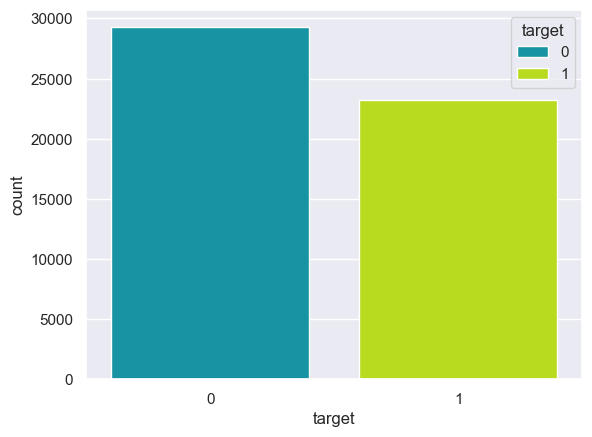

In [28]:
from collections import Counter
from matplotlib import pyplot as plt
import seaborn as sns

# Plot the imbalance between the targets 
print(sorted(Counter(y_train).items()))
sns.set_style('white')
sns.set(font_scale=1)
plt.figure()
sns.countplot(x=y_train, hue=y_train, palette='nipy_spectral')
plt.show()

In [29]:
# pip install --upgrade scikit-learn
# !pip install --upgrade xgboost lightgbm scikeras sklearn-compat

In [30]:
# C:\Users\ivano\AppData\Local\Programs\Python\Python312\Lib\site-packages\~~learn

[(0, 29276), (1, 29276)]


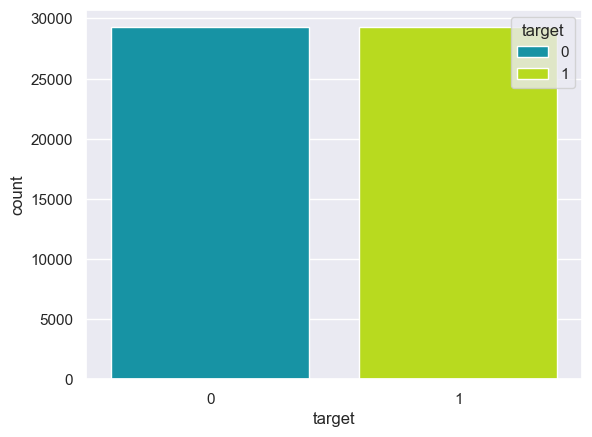

In [31]:
from imblearn.over_sampling import RandomOverSampler

# Balance targets with Synthetic Minority Oversampling Technique
# smote = SMOTE(random_state=0)
ros = RandomOverSampler()

X_train, y_train = ros.fit_resample(X_train, y_train)

# Plot the balance between classification targets 
print(sorted(Counter(y_train).items()))
sns.set_style('white')
sns.set(font_scale=1)
plt.figure()
sns.countplot(x=y_train, hue=y_train,palette='nipy_spectral')
plt.show()

In [32]:
# Print the shape of each part
print("Shapes:")
print("X_train: ", X_train.shape)
print("X_test:  ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test:  ", y_test.shape)

Shapes:
X_train:  (58552, 2)
X_test:   (14000, 2)
y_train:  (58552,)
y_test:   (14000,)


[<a href="#content">Back to top</a>]

 ## Machine Learning <a name="7"></a>

<a name="7"></a>

In [33]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Instantiate the algorithms that will be used, placing them in a dictionary 
clfs = {"SVM":SVC(),
        "Decision":DecisionTreeClassifier(), 
        "RandomForest":RandomForestClassifier(), 
        "GradientBoost":GradientBoostingClassifier(),
        "XGBoost":XGBClassifier(verbosity=0),
        "K-nearest": KNeighborsClassifier(n_neighbors=3)}

In [34]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

# Create statistics with the results of training with different algorithms
def model_fit(clfs):
    fitted_model={}
    model_result = pd.DataFrame()
    # Iterate the clfs dictionary clfs
    for model_name, model in clfs.items():
        # Train the current model
        model.fit(X_train,y_train)
        # Add the current model name
        fitted_model.update({model_name:model})
        # Prediction of the current model 
        y_pred = model.predict(X_test)
        model_dict = {}
        model_dict['Algorithm'] = model_name
        # Calculate the metrics
        model_dict['Accuracy'] = round(accuracy_score(y_test, y_pred),3)
        model_dict['Precision'] = round(precision_score(y_test, y_pred),3)
        model_dict['Recall'] = round(recall_score(y_test, y_pred),3)
        model_dict['F1'] = round(f1_score(y_test, y_pred),3)
        model_dict['ROC'] = round(roc_auc_score(y_test, y_pred),3)
        model_result = model_result._append(model_dict,ignore_index=True)
    return fitted_model, model_result

# Run the function model_fit(clfs) 
fitted_model, model_result = model_fit(clfs)

# Display the results of the model_fit(clfs) function in a descending order
model_result.sort_values(by=['Accuracy'],ascending=False)

,Algorithm,Accuracy,Precision,Recall,F1,ROC
4,XGBoost,0.787,0.852,0.694,0.765,0.787
2,RandomForest,0.784,0.830,0.715,0.768,0.784
3,GradientBoost,0.778,0.893,0.633,0.741,0.778
5,K-nearest,0.763,0.780,0.732,0.755,0.763
1,Decision,0.751,0.763,0.728,0.745,0.751
0,SVM,0.732,0.865,0.550,0.672,0.732


[<a href="#content">Back to top</a>]

 ## Cross-validation <a name="8"></a>

In [37]:
# Five-fold cross-validation 
import numpy as np 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline # Important for combining steps

# Print the proportion 
print(f"Original dataset shape: {X_cv.shape}, labels shape: {y_cv.shape}")
print(f"Class distribution (0: Majority, 1: Minority): {np.bincount(y_cv)}\n")

# Define the Model and Cross-Validation Strategy
model = RandomForestClassifier(random_state=42)

# Number of folds
n_splits = 5 

# Stratified K-Fold ensures balanced class distribution in each fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics from each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

# Cross-Validation Loop with Resampling
print(f"Performing {n_splits}-Fold Stratified Cross-Validation with RandomOverSAmpler...\n")

for fold, (train_index, test_index) in enumerate(skf.split(X_cv, y_cv)):
    print(f"--- Fold {fold + 1}/{n_splits} ---")

    # Split data for the current fold
    X_train_cv, X_test_cv = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_cv, y_test_cv = y_cv.iloc[train_index], y_cv.iloc[test_index]

    # StratifiedKFold ensures similar distribution in train/test
    print(f"  Training set class distribution: {np.bincount(y_train_cv)}")
    print(f"  Test set class distribution: {np.bincount(y_test_cv)}")

    # Define resampling strategy
    over_sampler_pipeline = Pipeline([
        ('oversample', RandomOverSampler(random_state=42))
    ])
    X_train_resampled, y_train_resampled = over_sampler_pipeline.fit_resample(X_train_cv, y_train_cv)
    print(f"  Training set (after SMOTE) class distribution: {np.bincount(y_train_resampled)}")

    # Train the model on the resampled training data
    model.fit(X_train_resampled, y_train_resampled)

    # Make predictions on the *original, untouched* test data
    y_pred_cv = model.predict(X_test_cv)
    y_prob_cv = model.predict_proba(X_test_cv)[:, 1] # Probability for the positive class (class 1)

    # Evaluate performance for the current fold
    accuracy = accuracy_score(y_test_cv, y_pred_cv)
    precision = precision_score(y_test_cv, y_pred_cv, zero_division=0) # zero_division=0 prevents warning if no true positives
    recall = recall_score(y_test_cv, y_pred_cv, zero_division=0)
    f1 = f1_score(y_test_cv, y_pred_cv, zero_division=0)
    roc_auc = roc_auc_score(y_test_cv, y_prob_cv)

    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Confusion Matrix:\n{confusion_matrix(y_test_cv, y_pred_cv)}\n")
    # print(classification_report(y_test, y_pred)) # Can print full report per fold
    print("-" * 30)


# Aggregate and Report Final Metrics
print("\n--- Cross-Validation Results Summary ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} +/- {np.std(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f} +/- {np.std(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f} +/- {np.std(recall_scores):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} +/- {np.std(f1_scores):.4f}")
print(f"Average ROC AUC: {np.mean(roc_auc_scores):.4f} +/- {np.std(roc_auc_scores):.4f}")

# Convert lists to NumPy arrays for easier manipulation (e.g., if you want to save them)
all_scores = {
    'accuracy': np.array(accuracy_scores),
    'precision': np.array(precision_scores),
    'recall': np.array(recall_scores),
    'f1_score': np.array(f1_scores),
    'roc_auc': np.array(roc_auc_scores)
}

Original dataset shape: (52518, 2), labels shape: (52518,)
Class distribution (0: Majority, 1: Minority): [29276 23242]

Performing 5-Fold Stratified Cross-Validation with RandomOverSAmpler...

--- Fold 1/5 ---
  Training set class distribution: [23420 18594]
  Test set class distribution: [5856 4648]
  Training set (after SMOTE) class distribution: [23420 23420]
  Accuracy: 0.7931
  Precision: 0.7973
  Recall: 0.7141
  F1-Score: 0.7534
  ROC AUC: 0.8569
  Confusion Matrix:
[[5012  844]
 [1329 3319]]

------------------------------
--- Fold 2/5 ---
  Training set class distribution: [23421 18593]
  Test set class distribution: [5855 4649]
  Training set (after SMOTE) class distribution: [23421 23421]
  Accuracy: 0.7914
  Precision: 0.8018
  Recall: 0.7023
  F1-Score: 0.7488
  ROC AUC: 0.8484
  Confusion Matrix:
[[5048  807]
 [1384 3265]]

------------------------------
--- Fold 3/5 ---
  Training set class distribution: [23421 18593]
  Test set class distribution: [5855 4649]
  Trainin

<a name="8"></a>

[<a href="#content">Back to top</a>]

 ## Scrutinise for overfitting <a name="9"></a>

<a name="9"></a>

In [38]:
# Evaluate random forest classifier performance on train and test sets with different tree depths
train_scores, test_scores = list(), list()
# define the tree depths to evaluate
values = [i for i in range(1, 21)]
# evaluate a decision tree for each depth
for i in values:
 # configure the model
 model_ = XGBClassifier(max_depth=i)
 # fit model_ on the training dataset
 model_.fit(X_train, y_train)
 # evaluate on the train dataset
 train_yhat = model_.predict(X_train)
 train_acc = accuracy_score(y_train, train_yhat)
 train_scores.append(train_acc)
 # evaluate on the test dataset
 test_yhat = model_.predict(X_test)
 test_acc = accuracy_score(y_test, test_yhat)
 test_scores.append(test_acc)
 # summarize progress
 print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>1, train: 0.762, test: 0.763
>2, train: 0.779, test: 0.778
>3, train: 0.787, test: 0.784
>4, train: 0.797, test: 0.786
>5, train: 0.804, test: 0.786
>6, train: 0.811, test: 0.787
>7, train: 0.819, test: 0.788
>8, train: 0.827, test: 0.788
>9, train: 0.833, test: 0.782
>10, train: 0.839, test: 0.783
>11, train: 0.846, test: 0.782
>12, train: 0.848, test: 0.780
>13, train: 0.851, test: 0.778
>14, train: 0.854, test: 0.775
>15, train: 0.858, test: 0.775
>16, train: 0.859, test: 0.773
>17, train: 0.861, test: 0.773
>18, train: 0.862, test: 0.771
>19, train: 0.864, test: 0.771
>20, train: 0.864, test: 0.769


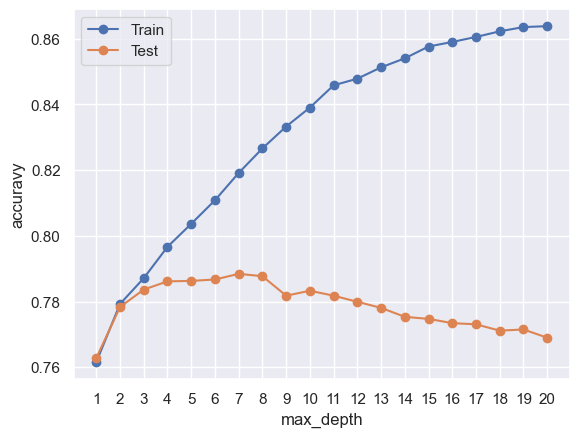

In [39]:
import math

# Set integers for x axis
new_x_ticks = range(math.floor(min(values)), math.ceil(max(values))+1)
plt.xticks(new_x_ticks)
# Plot of train and test scores vs tree depth
plt.plot(values, train_scores, '-o', label='Train')
plt.plot(values, test_scores, '-o', label='Test')
plt.legend()
plt.xlabel("max_depth")
plt.ylabel("accuravy")
plt.show()

In [40]:
# ML 
model= XGBClassifier(max_depth=9)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
acc = round(accuracy_score(y_test, y_pred),3)
print('Accuracy: ', acc)
pre = round(precision_score(y_test, y_pred),3)
print('Precision: ', pre) 
rec = round(recall_score(y_test, y_pred),3)
print('Recall: ',rec) 
f1 = round(f1_score(y_test, y_pred),3)
print('F1: ', f1) 
roc = round(roc_auc_score(y_test, y_pred),3) 
print('ROC: ', roc)

Accuracy:  0.782
Precision:  0.834
Recall:  0.704
F1:  0.763
ROC:  0.782


[<a href="#content">Back to top</a>]

## Plot the AUC <a name="10"></a>

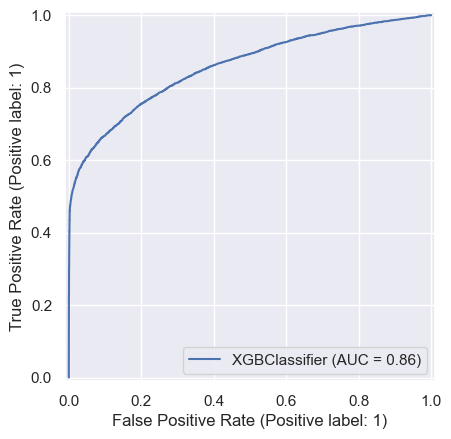

In [41]:
from sklearn.metrics import RocCurveDisplay

svc_disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

[<a href="#content">Back to top</a>]

## Confusion matrix, classification report <a name="13"></a>

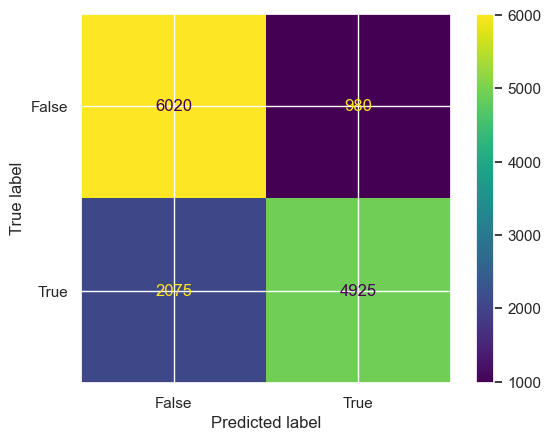

In [42]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

# Random forest classifier prediction
predicted = model.fit(X_train, y_train).predict(X_test)

# Calculate the confusion matrix
confusion_matrix = metrics.confusion_matrix(y_test, predicted)

# Display confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [43]:
# Classification report 
from sklearn.metrics import classification_report

# Print the classification report 
target_names = ['Active (target 1) ', 'Inactive (target 0)']
print(classification_report(y_test, predicted, target_names=target_names))

                     precision    recall  f1-score   support

 Active (target 1)        0.74      0.86      0.80      7000
Inactive (target 0)       0.83      0.70      0.76      7000

           accuracy                           0.78     14000
          macro avg       0.79      0.78      0.78     14000
       weighted avg       0.79      0.78      0.78     14000



[<a href="#content">Back to top</a>]